# <span style="color:red"> **LSN - Esercitazione 04**
### <span style="color:green"> 27.03.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:

#### Esercizio 04.1
- devo forse usare ceil() al posto che int() in measure nel calcolo di pofv per individuare il corretto bin? cioè arrotondare per eccesso: ad esempio, se mi capita che v = 2.12, incremento _index_pofv di 3, di modo che sia nel corretto bin che contiene velocità 2-3?
#### Esercizio 04.2
- Penso che il grafico che ho prodotto sia abbastanza illeggibile. Meglio plottare su grafici diversi? Perché nella consegna parla di grafici al plurale? Cos'altro posso plottare?
- capire come rispondere alla seconda domanda. nell'es 3
- come dati iniziali lascio quelli nel codice originario o modifico come da consegna? modidico. 
#### Esercizio 04.3
- ho modificato algoritmo di verlet mettendo segno - a set velocity.
- nel codice, leggo input direttamente da cartella di output dell'esercizio 04.2. Meglio incollare direttamente nell'input i dati dell'output dell'es 4.2., ed eventualmente modificarli a ogni nuova simulazione.

## <span style="color:blue">**Esercizio 04.1**

Ho incluso nel codice il calcolo della distribuzione $p(v*,T*)$. Il codice è già scritto in modo da fare data blocking.

## <span style="color:blue">**Esercizio 04.2**

Effettuo una stimulazione MD con un modello di Lennard-Jones per l'Argon, con parametri $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu, nelle seguenti condizioni:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

partendo da una configurazione iniziale a entropia molto bassa:
1. posizione iniziale delle particelle: cristallo fcc che occupa metà del box di simulazione in ogni dimensione
2. distribuzione di velocità iniziale: $p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$, dove $v_{T^*}$ è adeguatamente connessa $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

Mostro che, evolvendo una tale condizione iniale attraverso una simulazione di Dinamica Molecolare, la distribuzione di velocità tende ad approssimare la distribuzione di Maxwell-Boltzmann.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

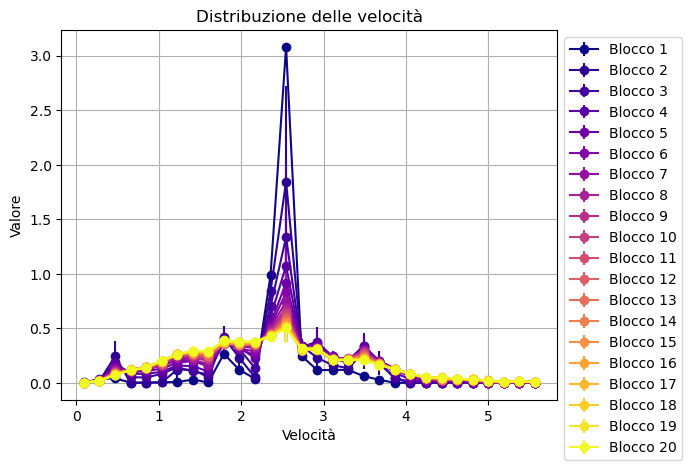

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Carico i dati dal file
data = np.loadtxt("04.2_NSL_SIMULATOR/OUTPUT/pofv.dat")

# Supponiamo che `data` sia un array numpy con i dati
x = data[:, 0]   # Prima colonna: velocità
y = data[:, 1]   # Seconda colonna: valori da plottare
err = data[:, 2] # Terza colonna: errore

# Definiamo una lista di colori (puoi usare una palette specifica se vuoi)
colors = plt.cm.plasma(np.linspace(0, 1, 20))  # 20 colori distinti da una colormap

# Numero di dati per blocco
block_size = 30

# Plot dei dati divisi in 20 blocchi
for i in range(20):
    start_idx = i * block_size
    end_idx = (i + 1) * block_size
    plt.errorbar(x[start_idx:end_idx], y[start_idx:end_idx], yerr=err[start_idx:end_idx], fmt='-o', color=colors[i], label=f'Blocco {i+1}')

# Aggiungi etichette e una legenda
plt.xlabel('Velocità')
plt.ylabel('Valore')
plt.title('Distribuzione delle velocità')
plt.legend()
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) #metto la legenda al di fuori del grafico per leggibilità

# Mostra il grafico
plt.show()


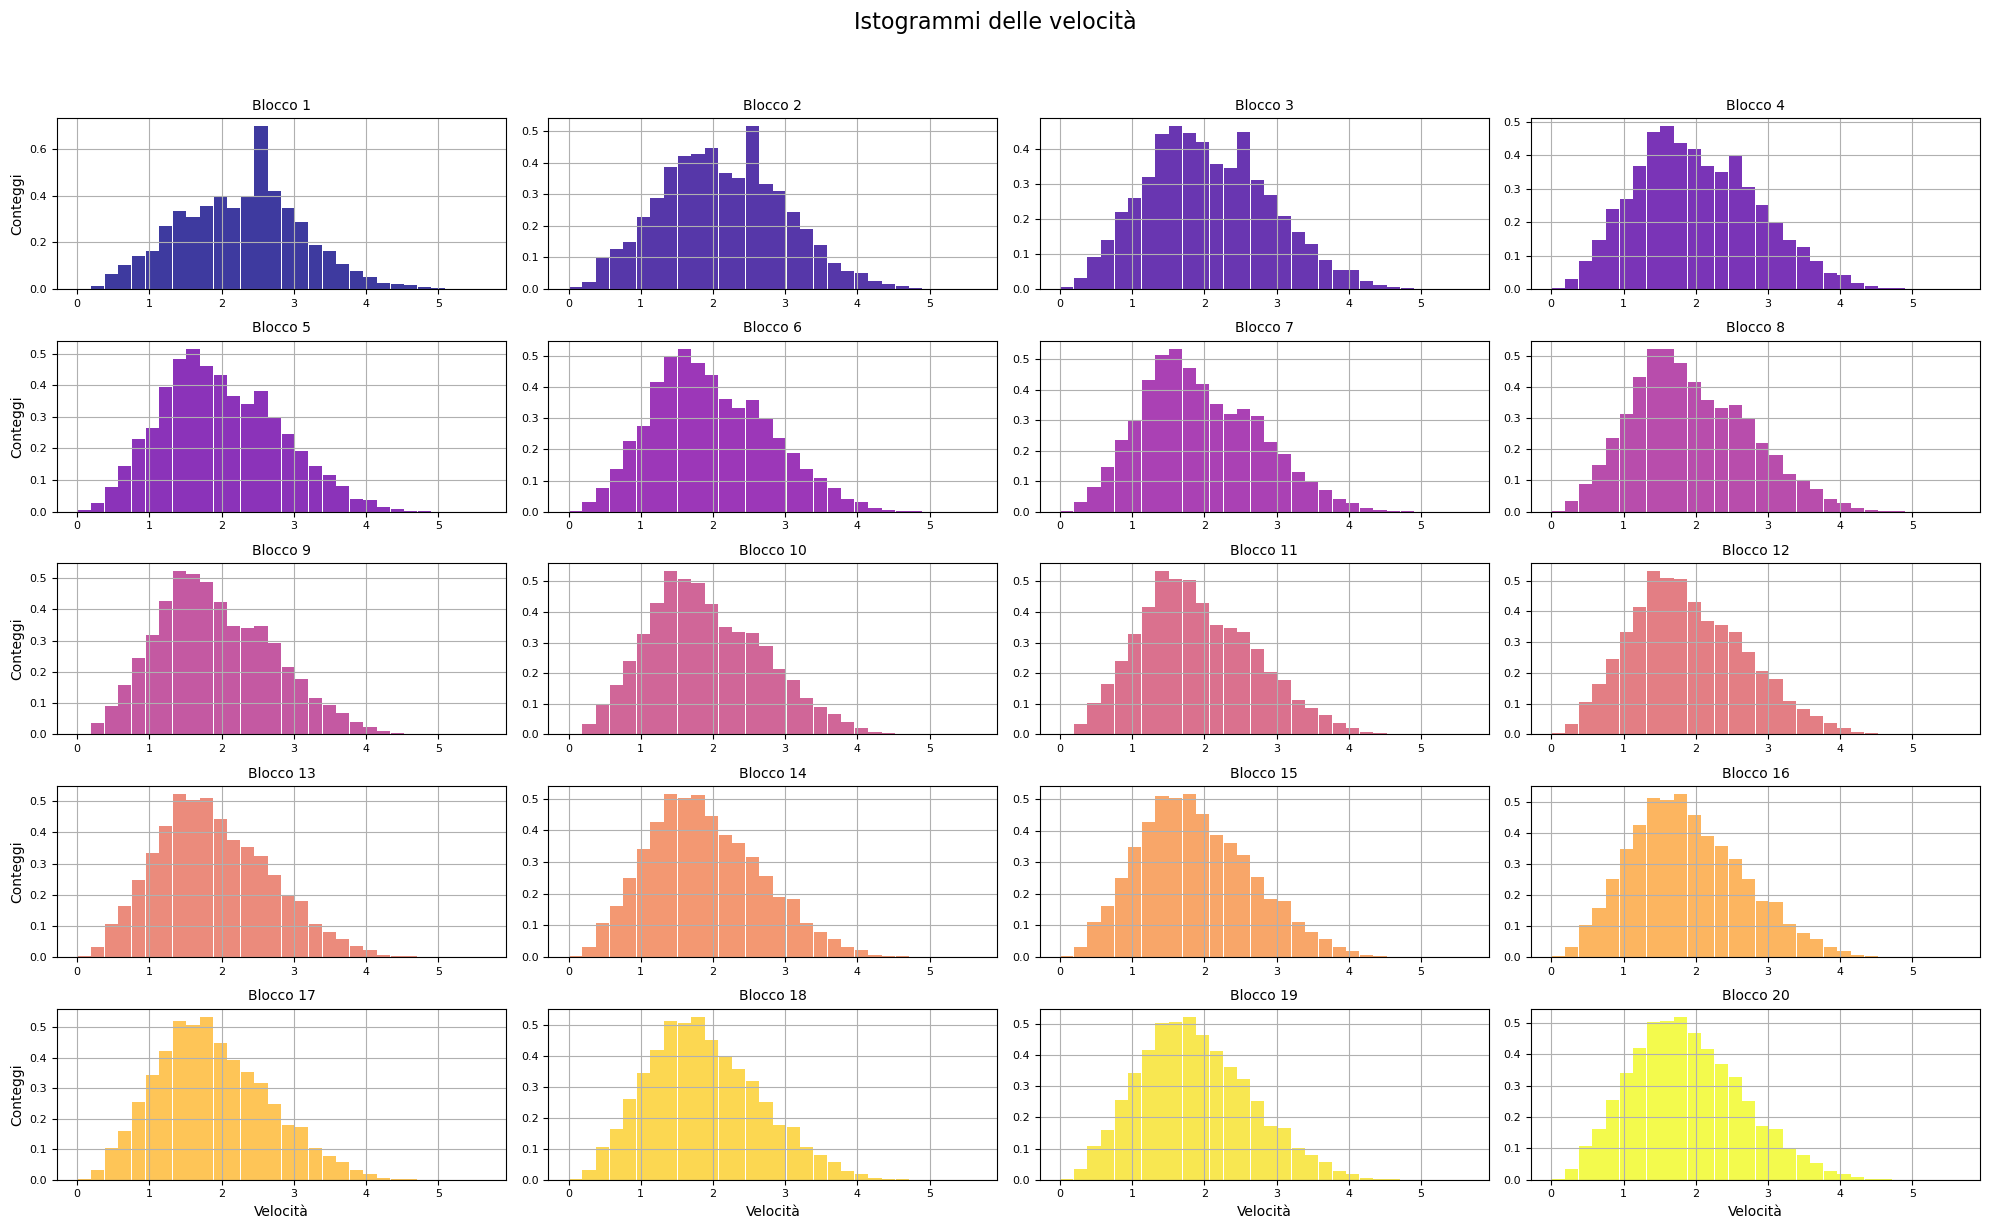

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Carico i dati dal file
data = np.loadtxt("04.2_NSL_SIMULATOR/OUTPUT/pofv.dat")

# Estraggo le colonne
x = data[:, 0]   # Velocità
y = data[:, 1]   # Conteggi già calcolati
err = data[:, 2] # Errori

# Parametri
colors = plt.cm.plasma(np.linspace(0, 1, 20))  # 20 colori distinti
block_size = 30
n_blocks = 20

# Crea figura con 20 subplot (5 righe x 4 colonne)
fig, axes = plt.subplots(5, 4, figsize=(20, 12))
axes = axes.flatten()  # Facilita l'indicizzazione

for i in range(n_blocks):
    start_idx = i * block_size
    end_idx = (i + 1) * block_size
    
    # Istogramma manuale usando plt.bar()
    axes[i].bar(x[start_idx:end_idx], y[start_idx:end_idx], color=colors[i], alpha=0.8, width=(x[end_idx-1] - x[start_idx]) / block_size)
    
    axes[i].set_title(f'Blocco {i+1}', fontsize=10)
    axes[i].grid(True)
    axes[i].tick_params(labelsize=8)

    # Etichette solo sui margini
    if i % 4 == 0:
        axes[i].set_ylabel('Conteggi')
    if i >= 16:
        axes[i].set_xlabel('Velocità')

# Layout e titolo generale
plt.tight_layout()
plt.suptitle('Istogrammi delle velocità', fontsize=16, y=1.02)
plt.subplots_adjust(top=0.93)

plt.show()



Ora inverto asse di percorrenza dei tempi per vedere se torno al cristallo con distribuzione omogenea di velocità iniziali e particelle che occupano metà del box di simulazione. 

## <span style="color:blue">**Esercizio 04.3**

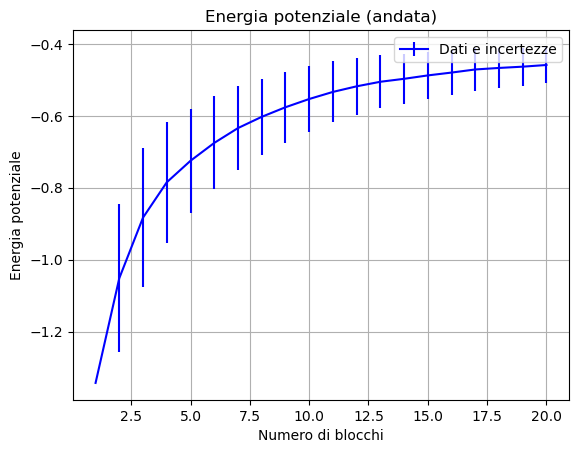

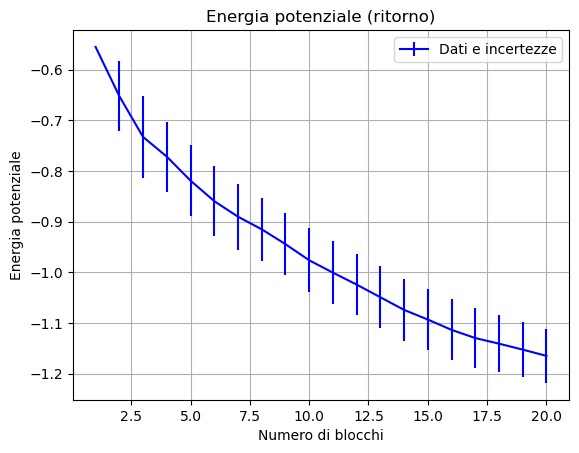

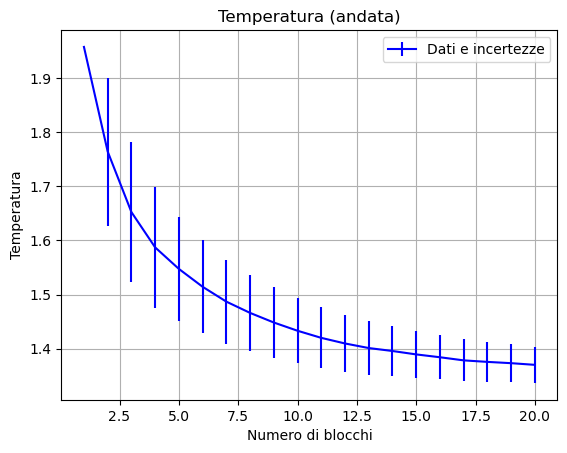

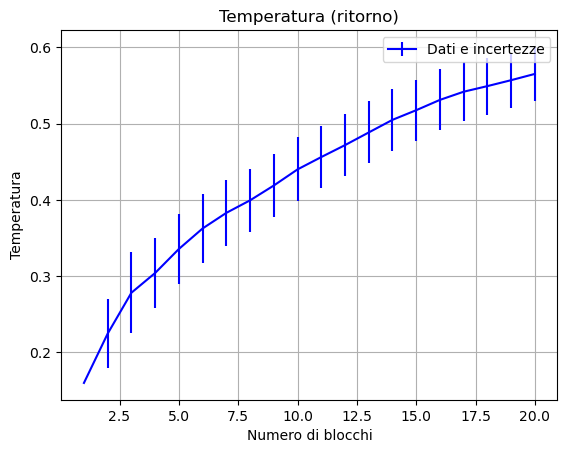

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# Carico i dati dal file
data_pot_andata = np.loadtxt("04.2_NSL_SIMULATOR/OUTPUT/potential_energy.dat")
data_pot_ritorno = np.loadtxt("04.3_NSL_SIMULATOR/OUTPUT/potential_energy.dat")
data_temp_andata = np.loadtxt("04.2_NSL_SIMULATOR/OUTPUT/temperature.dat")
data_temp_ritorno = np.loadtxt("04.3_NSL_SIMULATOR/OUTPUT/temperature.dat")

# Estraggo le colonne di dati
x_pot_andata = data_pot_andata[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y_pot_andata = data_pot_andata[:, 2]   # Terza colonna: differenza tra il valore medio di integrale ottenuto e il valore atteso
err_pot_andata = data_pot_andata[:, 3] # Quarta colonna: errore (deviazione standard)

x_temp_andata = data_temp_andata[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y_temp_andata = data_temp_andata[:, 2]   # Terza colonna: differenza tra il valore medio di integrale ottenuto e il valore atteso
err_temp_andata = data_temp_andata[:, 3] # Quarta colonna: errore (deviazione standard)

x_pot_ritorno = data_pot_ritorno[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y_pot_ritorno = data_pot_ritorno[:, 2]   # Terza colonna: differenza tra il valore medio di integrale ottenuto e il valore atteso
err_pot_ritorno = data_pot_ritorno[:, 3] # Quarta colonna: errore (deviazione standard)

x_temp_ritorno = data_temp_ritorno[:, 0]   # Prima colonna: contiene il numero di lanci nei blocchi considerati
y_temp_ritorno = data_temp_ritorno[:, 2]   # Terza colonna: differenza tra il valore medio di integrale ottenuto e il valore atteso
err_temp_ritorno = data_temp_ritorno[:, 3] # Quarta colonna: errore (deviazione standard)

# Creo il grafico con barre d'errore
plt.errorbar(x_pot_andata, y_pot_andata, yerr=err_pot_andata,label="Dati e incertezze",color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Energia potenziale")
plt.title("Energia potenziale (andata)")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(x_pot_ritorno, y_pot_ritorno, yerr=err_pot_ritorno,label="Dati e incertezze",color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Energia potenziale")
plt.title("Energia potenziale (ritorno)")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(x_temp_andata, y_temp_andata, yerr=err_temp_andata,label="Dati e incertezze",color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Temperatura")
plt.title("Temperatura (andata)")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(x_temp_ritorno, y_temp_ritorno, yerr=err_temp_ritorno,label="Dati e incertezze",color='b')
plt.xlabel("Numero di blocchi")
plt.ylabel("Temperatura")
plt.title("Temperatura (ritorno)")
plt.legend()
plt.grid()
plt.show()